# Курсовая

## Сбор инфы

In [3]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup

# Настройки для запуска Selenium
options = Options()
options.headless = True

service = Service(executable_path=r"C:\Users\georg\Downloads\chromedriver-win32\chromedriver-win32\chromedriver.exe")
driver = webdriver.Chrome(service=service, options=options)

base_url = 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse?tid=2277115'
all_links = []

# Проходим по страницам 1-10
for page in range(1, 11):
    url = f"{base_url}&page={page}"  # формируем URL страницы
    driver.get(url)

    WebDriverWait(driver, 20).until(
        EC.presence_of_all_elements_located((By.CSS_SELECTOR, 'a.relocation-programs-mo-link'))
    )

    html = driver.page_source
    soup = BeautifulSoup(html, 'html.parser')

    house_links = soup.select('a.relocation-programs-mo-link')
    
    # Фильтруем только дома из Кудрово
    for link in house_links:
        text = link.text.strip()
        if text.startswith("д. Кудрово") or text.startswith("г. Кудрово"):
            href = link.get('href')
            all_links.append(href)

driver.quit()

# Полные URL-адреса на страницы домов
full_links = [f'https://xn--80adsazqn.xn--p1aee.xn--p1ai{link}' for link in all_links]

print("Ссылки на дома в Кудрово:", full_links)

Ссылки на дома в Кудрово: ['https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9348364/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9084235/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9084237/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9371041/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9365027/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9365059/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9365060/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9365061/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9365062/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9365063/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9365064/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/9362555/', 'https://xn--80adsazqn.xn--p1aee.xn--p1ai/myhouse/profile/view/8677507/', 'https://xn

In [4]:
len(full_links)

109

In [5]:
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup

# Функция для извлечения данных по каждой ссылке с использованием уже открытого драйвера
def extract_house_info(driver, url):
    driver.get(url)

    WebDriverWait(driver, 20).until(
        EC.visibility_of_element_located((By.CSS_SELECTOR, '.house-description-address__title'))
    )

    html = driver.page_source
    soup = BeautifulSoup(html, 'html.parser')

    # Адрес
    address_elem = soup.select_one('.house-description-address__title')
    address = address_elem.text.strip() if address_elem else "Не найдено"

    # Численность жителей
    population_elem = soup.find('div', string="Численность жителей, чел.")
    if population_elem:
        population_value = population_elem.find_next('div', class_='f-16 fw-500')
        population = population_value.text.strip() if population_value else "Не найдено"
    else:
        population = "Не найдено"

    # Жилая площадь
    area_elem = soup.find('div', string="Общая площадь жилых помещений, кв.м")
    if area_elem:
        area_value = area_elem.find_next('div', class_='f-16 fw-500')
        area = area_value.text.strip().replace(" ", "") if area_value else "Не найдено"
    else:
        area = "Не найдено"

    return {
        "Адрес": address,
        "Численность жителей": population,
        "Жилая площадь": area
    }


# --- Использование ---
options = Options()
options.headless = True
service = Service(executable_path=r"C:\Users\georg\Downloads\chromedriver-win32\chromedriver-win32\chromedriver.exe")
driver = webdriver.Chrome(service=service, options=options)

data = []

for url in full_links:
    info = extract_house_info(driver, url)
    data.append(info)
    print(info)  # можно удалить, если выводить не нужно

driver.quit()

# Сохраняем в Excel и CSV
df = pd.DataFrame(data)
save_path = r"C:\Users\georg\NIS\Curse_work_2026\houses_data.xlsx"
df.to_excel(save_path, index=False)
df.to_csv(save_path.replace(".xlsx", ".csv"), index=False)

print(f"Данные успешно сохранены в:\n{save_path}\nи CSV: {save_path.replace('.xlsx', '.csv')}")

{'Адрес': 'Всеволожский р-н, Кудрово г, Итальянский пер, 4', 'Численность жителей': '1219', 'Жилая площадь': '48178,70'}
{'Адрес': 'Всеволожский р-н, Кудрово г, Австрийская ул, 4 к. 1', 'Численность жителей': '631', 'Жилая площадь': '31542,00'}
{'Адрес': 'Всеволожский р-н, Кудрово г, Австрийская ул, 4 к. 2', 'Численность жителей': '344', 'Жилая площадь': '17167,52'}
{'Адрес': 'Всеволожский р-н, Кудрово г, Английская ул, 2', 'Численность жителей': '2619', 'Жилая площадь': '71929,90'}
{'Адрес': 'Всеволожский р-н, Кудрово г, Английская ул, 3 к. 1', 'Численность жителей': '348', 'Жилая площадь': '9712,70'}
{'Адрес': 'Всеволожский р-н, Кудрово г, Английская ул, 3 к. 2', 'Численность жителей': '347', 'Жилая площадь': '9729,20'}
{'Адрес': 'Всеволожский р-н, Кудрово г, Английская ул, 3 к. 3', 'Численность жителей': '348', 'Жилая площадь': '9691,30'}
{'Адрес': 'Всеволожский р-н, Кудрово г, Английская ул, 3 к. 4', 'Численность жителей': '348', 'Жилая площадь': '9681,90'}
{'Адрес': 'Всеволожский 

In [6]:
print(df)

                                                 Адрес Численность жителей  \
0      Всеволожский р-н, Кудрово г, Итальянский пер, 4                1219   
1    Всеволожский р-н, Кудрово г, Австрийская ул, 4...                 631   
2    Всеволожский р-н, Кудрово г, Австрийская ул, 4...                 344   
3        Всеволожский р-н, Кудрово г, Английская ул, 2                2619   
4    Всеволожский р-н, Кудрово г, Английская ул, 3 ...                 348   
..                                                 ...                 ...   
104  обл. Ленинградская, д. Кудрово, пр-кт. Европей...          Не найдено   
105  обл. Ленинградская, д. Кудрово, пр-кт. Европей...          Не найдено   
106  обл. Ленинградская, д. Кудрово, пр-кт. Европей...          Не найдено   
107  обл. Ленинградская, д. Кудрово, пр-кт. Европей...          Не найдено   
108  обл. Ленинградская, д. Кудрово, пр-кт. Европей...          Не найдено   

    Жилая площадь  
0        48178,70  
1        31542,00  
2  

## Обработка массива

In [13]:
import pandas as pd
import numpy as np
import re

# Загружаем исходный файл
df = pd.read_csv(r"C:\Users\georg\NIS\Curse_work_2026\houses_data.csv")  # <-- замените на реальный файл

# 1. Заменяем "Не найдено" на NaN в нужных столбцах
for col in ["Численность жителей", "Жилая площадь"]:
    if col in df.columns:
        df[col] = df[col].replace("Не найдено", np.nan)

# Словарь для нормализации типов улиц
street_types = {
    r"\bул\b\.?": "улица",
    r"\bпр-кт\b\.?": "проспект",
    r"\bпер\b\.?": "переулок",
    r"\bаллея\b": "аллея",
    r"\bпл\b": "площадь",
    r"\bшоссе\b": "шоссе",
    r"\bбул\b": "бульвар"
}

def clean_address(addr):
    if pd.isna(addr):
        return addr
    
    # Убираем область, район, город, Всеволжский, микрорайоны
    addr = re.sub(r"(обл\. Ленинградская|Всеволожский р-?н|Всеволжский|д\.? Кудрово|Кудрово г|д Кудрово|р-н\.|мкр\.[^,]*|Новый Оккервиль мкр)", "", addr, flags=re.IGNORECASE)
    
    # Убираем "д." перед номером дома
    addr = re.sub(r"д\.?\s*", "", addr)
    
    # Корпус к формату кX (русская к)
    addr = re.sub(r"к\.?\s*(\d+)", r"к\1", addr)
    
    # Нормализуем типы улиц
    for pattern, replacement in street_types.items():
        addr = re.sub(pattern, replacement, addr, flags=re.IGNORECASE)
    
    # Поменять порядок: тип после названия
    def reorder(match):
        typ = match.group(1).lower()
        name = match.group(2).strip()
        return f"{name} {typ}"
    addr = re.sub(r"\b(улица|проспект|переулок|аллея|площадь|шоссе|бульвар)\s+([\w\s\-]+)", reorder, addr, flags=re.IGNORECASE)
    
    # Объединяем номер дома и корпус
    addr = re.sub(r",\s*(к\d+)", r" \1", addr)
    
    # Убираем лишние запятые и пробелы
    addr = re.sub(r"[,]+", ",", addr)
    addr = re.sub(r"\s+,", ",", addr)
    addr = re.sub(r",\s+", ", ", addr)
    addr = re.sub(r"\s+", " ", addr)
    addr = addr.strip(", ").strip()
    
    return addr

# Применяем очистку к столбцу "Адрес"
df['Адрес_clean'] = df['Адрес'].apply(clean_address)

# Сохраняем в Excel


In [14]:
df

,Адрес,Численность жителей,Жилая площадь,Адрес_clean
0,"Всеволожский р-н, Кудрово г, Итальянский пер, 4",1219,"48178,70","Итальянский переулок, 4"
1,"Всеволожский р-н, Кудрово г, Австрийская ул, 4...",631,"31542,00","Австрийская улица, 4 к1"
2,"Всеволожский р-н, Кудрово г, Австрийская ул, 4...",344,"17167,52","Австрийская улица, 4 к2"
3,"Всеволожский р-н, Кудрово г, Английская ул, 2",2619,"71929,90","Английская улица, 2"
4,"Всеволожский р-н, Кудрово г, Английская ул, 3 ...",348,"9712,70","Английская улица, 3 к1"
...,...,...,...,...
104,"обл. Ленинградская, д. Кудрово, пр-кт. Европей...",NaN,"5062,40","Европейский проспект, 20 к2"
105,"обл. Ленинградская, д. Кудрово, пр-кт. Европей...",NaN,"11169,90","Европейский проспект, 20 к3"
106,"обл. Ленинградская, д. Кудрово, пр-кт. Европей...",NaN,"11163,30","Европейский проспект, 20 к4"
107,"обл. Ленинградская, д. Кудрово, пр-кт. Европей...",NaN,"37225,20","Европейский проспект, 21 к2"


In [15]:
df.to_excel(r"C:\Users\georg\NIS\Curse_work_2026\чистые_адреса.xlsx", index=False)

## Мёрджинг таблиц

In [2]:
import pandas as pd

data_square = pd.read_excel(r"C:\Users\georg\NIS\Curse_work_2026\чистые_адреса.xlsx")
data_square.head(5)

,Адрес,Численность жителей,Жилая площадь,Адрес_clean
0,"Всеволожский р-н, Кудрово г, Итальянский пер, 4",1219.0,"48178,70","Итальянский переулок, 4"
1,"Всеволожский р-н, Кудрово г, Австрийская ул, 4...",631.0,"31542,00","Австрийская улица, 4 к1"
2,"Всеволожский р-н, Кудрово г, Австрийская ул, 4...",344.0,"17167,52","Австрийская улица, 4 к2"
3,"Всеволожский р-н, Кудрово г, Английская ул, 2",2619.0,"71929,90","Английская улица, 2"
4,"Всеволожский р-н, Кудрово г, Английская ул, 3 ...",348.0,"9712,70","Английская улица, 3 к1"


In [10]:
data_adresses = pd.read_csv(r"C:\Users\georg\NIS\Curse_work_2026\buildings_Kudrovo.csv", encoding='utf-8')
data_adresses.columns

Index(['X', 'Y', 'full_id', 'osm_id', 'osm_type', 'building',
       'building:cladding', 'design:year', 'design:ref', 'design:code:SPb',
       'height', 'source:geometry', 'roof:colour', 'building:colour',
       'operator', 'roof:levels', 'building:year_built', 'building:material',
       'start_date', 'description', 'building:levels:underground',
       'addr:postcode', 'addr:country', 'website', 'building:flats',
       'energy_class', 'source:addr', 'addr:city', 'roof:shape', 'name',
       'developer', 'type', 'building:levels', 'addr:street',
       'addr:housenumber', 'full_id_2', 'osm_id_2', 'osm_type_2', 'building_2',
       'parking', 'capacity', 'amenity', 'access', 'power', 'source:addr_2',
       'addr:postcode_2', 'start_date_2', 'height_2', 'energy_class_2',
       'building:levels:underground_2', 'building:flats_2', 'type_2',
       'roof:shape_2', 'developer_2', 'building:levels_2', 'addr:street_2',
       'addr:housenumber_2', 'addr:country_2', 'addr:city_2'],
     

In [15]:
data_adresses = data_adresses[['X', 'Y', 'addr:street', 'addr:housenumber']]
street_col = "addr:street"
house_col = "addr:housenumber"

data_adresses["Адрес_clean"] = data_adresses[street_col].fillna("").str.strip() + ", " + data_adresses[house_col].fillna("").astype(str).str.strip()
data_adresses.head()

,X,Y,addr:street,addr:housenumber,Адрес_clean
0,30.509818,59.902949,Австрийская улица,4 к1,"Австрийская улица, 4 к1"
1,30.506173,59.916037,Областная улица,1,"Областная улица, 1"
2,30.511644,59.901377,Европейский проспект,9 к1,"Европейский проспект, 9 к1"
3,30.511828,59.902199,Европейский проспект,9 к2,"Европейский проспект, 9 к2"
4,30.509600,59.904485,Европейский проспект,13 к1,"Европейский проспект, 13 к1"


In [16]:
merged_data = pd.merge(data_adresses, data_square, on='Адрес_clean', how='left')
merged_data.head()

,X,Y,addr:street,addr:housenumber,Адрес_clean,Адрес,Численность жителей,Жилая площадь
0,30.509818,59.902949,Австрийская улица,4 к1,"Австрийская улица, 4 к1","Всеволожский р-н, Кудрово г, Австрийская ул, 4...",631.0,"31542,00"
1,30.506173,59.916037,Областная улица,1,"Областная улица, 1","Всеволожский р-н, Кудрово г, Новый Оккервиль м...",3708.0,"187050,45"
2,30.511644,59.901377,Европейский проспект,9 к1,"Европейский проспект, 9 к1","Всеволожский р-н, Кудрово г, Европейский пр-кт...",300.0,"8184,90"
3,30.511828,59.902199,Европейский проспект,9 к2,"Европейский проспект, 9 к2","Всеволожский р-н, Кудрово г, Европейский пр-кт...",300.0,"6874,50"
4,30.509600,59.904485,Европейский проспект,13 к1,"Европейский проспект, 13 к1","Всеволожский р-н, Кудрово г, Европейский пр-кт...",378.0,"18887,20"


In [18]:
df = merged_data.drop(['addr:street', 'addr:housenumber'], axis=1)
df.head()

,X,Y,Адрес_clean,Адрес,Численность жителей,Жилая площадь
0,30.509818,59.902949,"Австрийская улица, 4 к1","Всеволожский р-н, Кудрово г, Австрийская ул, 4...",631.0,"31542,00"
1,30.506173,59.916037,"Областная улица, 1","Всеволожский р-н, Кудрово г, Новый Оккервиль м...",3708.0,"187050,45"
2,30.511644,59.901377,"Европейский проспект, 9 к1","Всеволожский р-н, Кудрово г, Европейский пр-кт...",300.0,"8184,90"
3,30.511828,59.902199,"Европейский проспект, 9 к2","Всеволожский р-н, Кудрово г, Европейский пр-кт...",300.0,"6874,50"
4,30.509600,59.904485,"Европейский проспект, 13 к1","Всеволожский р-н, Кудрово г, Европейский пр-кт...",378.0,"18887,20"


In [19]:
df.to_excel(r"C:\Users\georg\NIS\Curse_work_2026\data_houses_Kudrovo.xlsx", index=False)

## Перенастройка парсера (?)

In [21]:
from rapidfuzz import fuzz, process

table_address = "Английская улица, 12"
site_address = "Всеволжский р-н, г. Кудрово, ул. Английская, д. 12"

# Считаем похожесть двух строк
score = fuzz.token_sort_ratio(table_address, site_address)
print(score)  # 0-100, чем выше — тем лучше совпадение

48.57142857142858


In [1]:
import pymorphy2
from rapidfuzz import fuzz

morph = pymorphy2.MorphAnalyzer()

def normalize_address(addr):
    words = addr.lower().replace(',', '').split()
    normalized = []
    for w in words:
        p = morph.parse(w)[0]
        normalized.append(p.normal_form)
    return " ".join(normalized)

addr1 = normalize_address("Английская улица, 12")
addr2 = normalize_address("Всеволжский р-н, г. Кудрово, ул. Английская, д. 12")

score = fuzz.token_sort_ratio(addr1, addr2)
print(score)

C:\Users\georg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


AttributeError: module 'inspect' has no attribute 'getargspec'

## Восстановаление пропусков

In [38]:
import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_excel(r"C:\Users\georg\Downloads\data_houses_kudrovo_почищенный_таргет.xlsx")
df = df.drop(columns=['Адрес'])
df = df.dropna()
df.head()

,X,Y,Адрес_clean,Численность жителей,Жилая площадь
0,30.509818,59.902949,"Австрийская улица, 4 к1",631.0,"31542,00"
1,30.506173,59.916037,"Областная улица, 1",3708.0,"187050,45"
2,30.511644,59.901377,"Европейский проспект, 9 к1",300.0,"8184,90"
3,30.511828,59.902199,"Европейский проспект, 9 к2",300.0,"6874,50"
4,30.509600,59.904485,"Европейский проспект, 13 к1",378.0,"18887,20"


In [39]:
len(df)

100

In [41]:
df = df.rename(columns={'Численность жителей': 'flats',
                        'Жилая площадь': 'living_area'})

# Заменяем запятую на точку и приводим к числу
df['living_area'] = df['living_area'].astype(str).str.replace(',', '.').str.replace(r'[^\d.]', '', regex=True)
df['living_area'] = pd.to_numeric(df['living_area'], errors='coerce')

# Для flats — тоже очистка на всякий случай
df['flats'] = df['flats'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['flats'] = pd.to_numeric(df['flats'], errors='coerce')

# Убираем строки с пустыми или некорректными числами
df = df.dropna(subset=['living_area', 'flats'])
len(df)

100

In [42]:
model = smf.ols('living_area ~ flats', data=df).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            living_area   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     42.24
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           3.39e-09
Time:                        19:48:20   Log-Likelihood:                -1042.5
No. Observations:                 100   AIC:                             2089.
Df Residuals:                      98   BIC:                             2094.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -556.5714   2956.787     -0.188      0.8

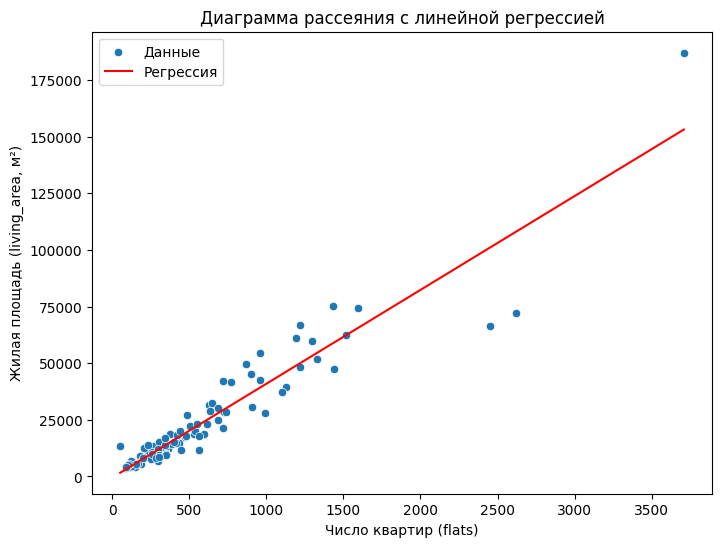

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='flats', y='living_area', data=df, label='Данные')
sns.lineplot(x=df['flats'], y=model.fittedvalues, color='red', label='Регрессия')
plt.xlabel('Число квартир (flats)')
plt.ylabel('Жилая площадь (living_area, м²)')
plt.title('Диаграмма рассеяния с линейной регрессией')
plt.legend()
plt.show()

                            OLS Regression Results                            
Dep. Variable:            living_area   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     339.4
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           4.05e-33
Time:                        19:50:07   Log-Likelihood:                -972.33
No. Observations:                  97   AIC:                             1949.
Df Residuals:                      95   BIC:                             1954.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1554.6136    939.472     -1.655      0.0

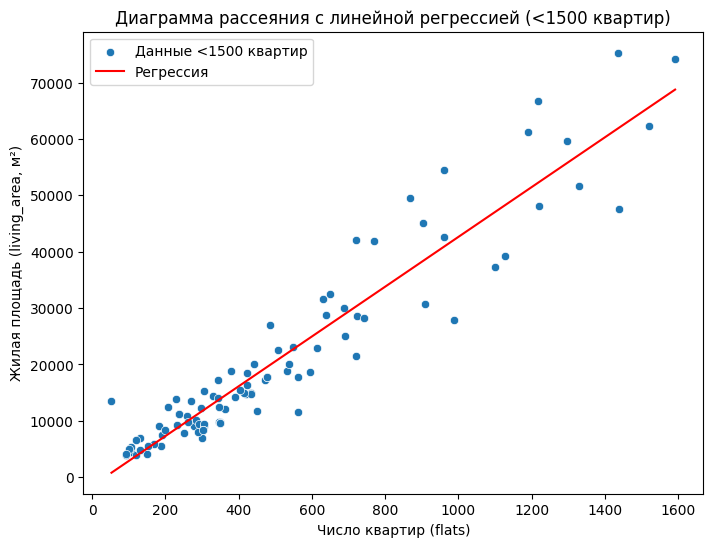

In [44]:
# Фильтруем строки с количеством квартир < 1500
df2000 = df[df['flats'] < 2000]

# Строим модель на этом подмножестве
model2000 = smf.ols('living_area ~ flats', data=df2000).fit(cov_type='HC3')
print(model2000.summary())

# График рассеяния + линия регрессии
plt.figure(figsize=(8,6))
sns.scatterplot(x='flats', y='living_area', data=df2000, label='Данные <1500 квартир')
sns.lineplot(x=df2000['flats'], y=model2000.fittedvalues, color='red', label='Регрессия')
plt.xlabel('Число квартир (flats)')
plt.ylabel('Жилая площадь (living_area, м²)')
plt.title('Диаграмма рассеяния с линейной регрессией (<1500 квартир)')
plt.legend()
plt.show()

In [45]:
pd.set_option('display.max_rows', None)  # Показать все строки
pd.set_option('display.max_columns', None)  # Показать все столбцы
print(df)

             X          Y                  Адрес_clean   flats  living_area
0    30.509818  59.902949      Австрийская улица, 4 к1   631.0     31542.00
1    30.506173  59.916037           Областная улица, 1  3708.0    187050.45
2    30.511644  59.901377   Европейский проспект, 9 к1   300.0      8184.90
3    30.511828  59.902199   Европейский проспект, 9 к2   300.0      6874.50
4    30.509600  59.904485  Европейский проспект, 13 к1   378.0     18887.20
5    30.510287  59.904003  Европейский проспект, 13 к3   184.0      9163.50
6    30.510739  59.900322          Венская улица, 4 к2   724.0     28580.60
7    30.508436  59.900633          Венская улица, 4 к1   532.0     18908.10
8    30.511069  59.905196  Европейский проспект, 13 к2   539.0     20112.27
9    30.510393  59.899301      Европейский проспект, 5   690.0     24987.60
10   30.510268  59.913954       Ленинградская улица, 5   903.0     45119.65
11   30.511685  59.904602  Европейский проспект, 13 к4   233.0      9288.40
12   30.5065

### Теперь предикт

In [46]:
data = pd.read_excel(r"C:\Users\georg\Downloads\выборка_для_предикта.xlsx")
data.head(11)

,X,Y,Адрес_clean,Адрес,Численность жителей,Жилая площадь
0,30.517807,59.899523,"Столичная улица, 4 к2","Всеволожский р-н, Кудрово г, Столичная ул, 4 к. 2",351,NaN
1,30.515981,59.899755,"Столичная улица, 4 к4","Всеволожский р-н, Кудрово г, Столичная ул, 4 к. 4",430,NaN
2,30.515222,59.899148,"Столичная улица, 4","Всеволожский р-н, Кудрово г, Столичная ул, 4",294,NaN
3,30.516682,59.900437,"Столичная улица, 4 к3","Всеволожский р-н, Кудрово г, Столичная ул, 4 к. 3",576,NaN
4,30.516563,59.898940,"Столичная улица, 4 к1","Всеволожский р-н, Кудрово г, Столичная ул, 4 к. 1",168,NaN
5,30.518280,59.898278,"Столичная улица, 5 к2","Всеволожский р-н, Кудрово г, Столичная ул, 5 к. 2",464,NaN
6,30.515939,59.898215,"Столичная улица, 5","Всеволожский р-н, Кудрово г, Столичная ул, 5",335,NaN
7,30.517107,59.898187,"Столичная улица, 5 к1","Всеволожский р-н, Кудрово г, Столичная ул, 5 к. 1",351,NaN
8,30.520494,59.900232,"проспект Строителей, 20",NaN,698,NaN
9,30.518336,59.922525,"проспект Строителей, 1 к1",NaN,767,NaN


In [48]:
data = data.rename(columns={'Численность жителей': 'flats',
                        'Жилая площадь': 'living_area'})

x = data['flats']
y = model2000.predict(x)

In [50]:
print(x, y)

0    351
1    430
2    294
3    576
4    168
5    464
6    335
7    351
8    698
9    767
Name: flats, dtype: int64 0    13947.424849
1    17436.487639
2    11429.999799
3    23884.628996
4     5865.165477
5    18938.109598
6    13240.779221
7    13947.424849
8    29272.801911
9    32320.211182
dtype: float64


## Парс существующих маршрутiв

In [1]:
import asyncio
import json
import re
from pathlib import Path
from urllib.parse import quote_plus

import pandas as pd
from playwright.async_api import async_playwright, TimeoutError as PlaywrightTimeoutError


ROUTES = {
    "492А": {"directions": "both"},
    "596": {"directions": "both"},
    "596А": {"directions": "both"},
    "596Б": {"directions": "both"},
    "692": {"directions": "one"},
}

CITY_HINT = "Кудрово"
OUT_DIR = Path("yandex_bus_routes")
OUT_DIR.mkdir(exist_ok=True)

YANDEX_MAPS_URL = "https://yandex.ru/maps/"


BAD_STOP_TEXT_PATTERNS = [
    r"^маршрут",
    r"^расписание",
    r"^на карте",
    r"^сохранить",
    r"^поделиться",
    r"^построить",
    r"^показать",
    r"^все остановки",
    r"^остановки",
    r"^сейчас",
    r"^завтра",
    r"^\d+\s*мин",
    r"^\d{1,2}:\d{2}$",
]


def normalize_text(text: str) -> str:
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def looks_like_stop_name(text: str) -> bool:
    text = normalize_text(text)

    if not text:
        return False

    if len(text) < 3 or len(text) > 90:
        return False

    lower = text.lower()

    for pattern in BAD_STOP_TEXT_PATTERNS:
        if re.search(pattern, lower):
            return False

    if lower in {
        "автобус",
        "общественный транспорт",
        "как добраться",
        "закрыть",
        "назад",
        "ещё",
        "еще",
    }:
        return False

    # Убираем строки, которые выглядят как набор времени прибытия.
    if re.fullmatch(r"[\d:\s–—-]+", text):
        return False

    return True


async def wait_for_manual_if_needed(page, route_number: str):
    print()
    print(f"Открыл Яндекс Карты для маршрута {route_number}.")
    print("Если видишь капчу — реши её в браузере.")
    print("Если карточка маршрута не открылась сама — выбери нужный автобус вручную.")
    print("Когда карточка маршрута открыта, нажми Enter здесь.")
    await asyncio.to_thread(input)


async def scroll_sidebar(page):
    """
    Скроллим левую панель, чтобы Яндекс подгрузил все остановки.
    Селекторы у Яндекса могут меняться, поэтому используем несколько вариантов.
    """
    await page.evaluate(
        """
        async () => {
            const candidates = [
                document.querySelector('[class*="sidebar"]'),
                document.querySelector('[class*="scroll"]'),
                document.querySelector('aside'),
                document.body
            ].filter(Boolean);

            const el = candidates[0];

            for (let i = 0; i < 12; i++) {
                el.scrollBy(0, 900);
                await new Promise(r => setTimeout(r, 250));
            }

            for (let i = 0; i < 12; i++) {
                el.scrollBy(0, -900);
                await new Promise(r => setTimeout(r, 100));
            }
        }
        """
    )


async def extract_visible_stops(page):
    """
    Пытаемся собрать названия остановок из видимых элементов.
    Основной упор — на DOM-элементы, в className которых есть stop/station.
    """
    raw_items = await page.evaluate(
        """
        () => {
            const selectors = [
                '[class*="stop"]',
                '[class*="Stop"]',
                '[class*="station"]',
                '[class*="Station"]',
                'li',
                '[role="listitem"]'
            ];

            const nodes = Array.from(document.querySelectorAll(selectors.join(',')));

            function isVisible(el) {
                const rect = el.getBoundingClientRect();
                const style = window.getComputedStyle(el);
                return (
                    rect.width > 0 &&
                    rect.height > 0 &&
                    style.visibility !== 'hidden' &&
                    style.display !== 'none'
                );
            }

            return nodes
                .filter(isVisible)
                .map(el => ({
                    text: el.innerText || el.textContent || '',
                    className: String(el.className || ''),
                    tag: el.tagName
                }));
        }
        """
    )

    stops = []
    seen = set()

    for item in raw_items:
        text = normalize_text(item["text"])

        # Иногда в одном элементе несколько строк.
        parts = [normalize_text(x) for x in re.split(r"[\n\r]+", text)]
        for part in parts:
            if not looks_like_stop_name(part):
                continue

            key = part.lower()
            if key not in seen:
                seen.add(key)
                stops.append(part)

    return stops


async def find_direction_buttons(page):
    """
    Ищем кнопки/табы, которые могут переключать направление.
    У Яндекса это может быть кнопка, div role=button или ссылка.
    """
    buttons = await page.evaluate(
        """
        () => {
            const nodes = Array.from(document.querySelectorAll(
                'button, [role="button"], a, [class*="tab"], [class*="direction"]'
            ));

            function isVisible(el) {
                const rect = el.getBoundingClientRect();
                const style = window.getComputedStyle(el);
                return (
                    rect.width > 0 &&
                    rect.height > 0 &&
                    style.visibility !== 'hidden' &&
                    style.display !== 'none'
                );
            }

            return nodes
                .filter(isVisible)
                .map((el, index) => ({
                    index,
                    text: (el.innerText || el.textContent || '').trim(),
                    className: String(el.className || ''),
                    tag: el.tagName
                }));
        }
        """
    )

    candidates = []

    for b in buttons:
        text = normalize_text(b["text"])
        lower = text.lower()

        if not text:
            continue

        # Часто направления выглядят как "А → Б" или содержат конечные остановки.
        direction_like = (
            "→" in text
            or "↔" in text
            or "обратно" in lower
            or "туда" in lower
            or "направление" in lower
            or "до " in lower
        )

        if direction_like and len(text) <= 120:
            candidates.append(b)

    # Удаляем дубли по тексту.
    unique = []
    seen = set()
    for c in candidates:
        key = c["text"].lower()
        if key not in seen:
            seen.add(key)
            unique.append(c)

    return unique


async def click_button_by_index(page, button_index: int):
    await page.evaluate(
        """
        async (buttonIndex) => {
            const nodes = Array.from(document.querySelectorAll(
                'button, [role="button"], a, [class*="tab"], [class*="direction"]'
            ));

            const el = nodes[buttonIndex];
            if (el) {
                el.scrollIntoView({block: 'center'});
                await new Promise(r => setTimeout(r, 200));
                el.click();
            }
        }
        """,
        button_index,
    )


async def open_route_card(page, route_number: str):
    query = quote_plus(f"автобус {route_number} {CITY_HINT}")
    url = f"{YANDEX_MAPS_URL}?text={query}"

    await page.goto(url, wait_until="domcontentloaded", timeout=60_000)
    await page.wait_for_timeout(5_000)

    # Пробуем автоматически кликнуть по результату с номером маршрута.
    # Если не получится — пользователь выберет вручную.
    try:
        route_regex = re.compile(rf"\b{re.escape(route_number)}\b", re.IGNORECASE)

        candidates = page.get_by_text(route_regex)
        count = await candidates.count()

        if count > 0:
            await candidates.first.click(timeout=5_000)
            await page.wait_for_timeout(4_000)

    except Exception:
        pass


async def scrape_route(page, route_number: str, directions_mode: str):
    await open_route_card(page, route_number)
    await wait_for_manual_if_needed(page, route_number)

    await scroll_sidebar(page)

    result = {
        "route_number": route_number,
        "directions_mode": directions_mode,
        "source": "Yandex Maps visible route card",
        "directions": [],
    }

    direction_buttons = await find_direction_buttons(page)

    if directions_mode == "one":
        stops = await extract_visible_stops(page)

        result["directions"].append(
            {
                "direction_index": 1,
                "direction_name": "one_direction",
                "stops": stops,
                "stops_count": len(stops),
            }
        )

        return result

    # Для обеих сторон пробуем найти 2 переключателя направления.
    # Если не нашли — всё равно сохраняем текущее направление,
    # а второе можно будет открыть вручную при повторном запуске.
    if len(direction_buttons) >= 2:
        for i, button in enumerate(direction_buttons[:2], start=1):
            await click_button_by_index(page, button["index"])
            await page.wait_for_timeout(2_000)
            await scroll_sidebar(page)

            stops = await extract_visible_stops(page)

            result["directions"].append(
                {
                    "direction_index": i,
                    "direction_name": normalize_text(button["text"]) or f"direction_{i}",
                    "stops": stops,
                    "stops_count": len(stops),
                }
            )
    else:
        stops = await extract_visible_stops(page)

        result["directions"].append(
            {
                "direction_index": 1,
                "direction_name": "current_visible_direction",
                "stops": stops,
                "stops_count": len(stops),
                "warning": "Не удалось автоматически найти переключатель второго направления.",
            }
        )

    return result


def save_outputs(all_results):
    json_path = OUT_DIR / "bus_routes.json"
    csv_path = OUT_DIR / "bus_routes_stops.csv"

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(all_results, f, ensure_ascii=False, indent=2)

    rows = []

    for route in all_results:
        route_number = route["route_number"]

        for direction in route["directions"]:
            direction_index = direction["direction_index"]
            direction_name = direction["direction_name"]

            for stop_index, stop_name in enumerate(direction["stops"], start=1):
                rows.append(
                    {
                        "route_number": route_number,
                        "direction_index": direction_index,
                        "direction_name": direction_name,
                        "stop_index": stop_index,
                        "stop_name": stop_name,
                    }
                )

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")

    print()
    print(f"Готово:")
    print(f"JSON: {json_path}")
    print(f"CSV:  {csv_path}")


async def main():
    all_results = []

    async with async_playwright() as p:
        browser = await p.chromium.launch(
            headless=False,
            slow_mo=150,
        )

        context = await browser.new_context(
            locale="ru-RU",
            viewport={"width": 1440, "height": 1000},
        )

        page = await context.new_page()

        for route_number, config in ROUTES.items():
            print("=" * 80)
            print(f"Маршрут: {route_number}")

            try:
                result = await scrape_route(
                    page=page,
                    route_number=route_number,
                    directions_mode=config["directions"],
                )

                all_results.append(result)

                route_path = OUT_DIR / f"bus_{route_number}.json"
                with open(route_path, "w", encoding="utf-8") as f:
                    json.dump(result, f, ensure_ascii=False, indent=2)

                print(f"Сохранено: {route_path}")

            except PlaywrightTimeoutError:
                print(f"Таймаут на маршруте {route_number}. Пропускаю.")
            except Exception as e:
                print(f"Ошибка на маршруте {route_number}: {e}")

        await browser.close()

    save_outputs(all_results)


if __name__ == "__main__":
    asyncio.run(main())

RuntimeError: asyncio.run() cannot be called from a running event loop

## Построение OD-матрицы до остановок

In [1]:
# ============================================================
# OD-матрица: подъезды → остановки по пешеходной сети
# ============================================================

# pip install geopandas momepy networkx numpy pandas scipy

import geopandas as gpd
import momepy
import networkx as nx
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

# ============================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================

CRS = "EPSG:32636"  # UTM зона 36N — метры, подходит для СПб

entrances = gpd.read_file('C:/Users/georg/Downloads/paradniye_with_pop_v2.gpkg').to_crs(CRS)
stops     = gpd.read_file(r"C:\Users\georg\NIS\Curse_work_2026\bus_stops_v2.gpkg").to_crs(CRS)
edges     = gpd.read_file(r"C:\Users\georg\NIS\Curse_work_2026\kud_pedestr_v2.gpkg").to_crs(CRS)

# Убедись что поля есть
print("Подъезды:", entrances.shape, list(entrances.columns))
print("Остановки:", stops.shape,   list(stops.columns))
print("Рёбра:",    edges.shape,    list(edges.columns))


Подъезды: (621, 23) ['full_id', 'osm_id', 'osm_type', 'entrance', 'addr:housenumber', 'level', 'addr:street', 'addr:city', 'door', 'access', 'wheelchair', 'ref', 'addr:flats', 'n_flats', 'home_idx', 'home_dist', 'match_type', 'home_addr', 'home_pop', 'imputed_flats', 'n_flats_used', 'population', 'geometry']
Остановки: (51, 17) ['full_id', 'osm_id', 'osm_type', 'highway', 'name:signed', 'departures_board', 'share_taxi', 'lit', 'trolleybus', 'tactile_paving', 'shelter', 'public_transport', 'name', 'bus', 'bin', 'bench', 'geometry']
Рёбра: (10185, 78) ['full_id', 'osm_id', 'osm_type', 'conveying', 'handrail:right', 'handrail:left', 'maxspeed:practical', 'start_date', 'turn:lanes', 'parking:lane:both', 'maxweight:signed', 'old_name', 'step_count', 'ramp', 'handrail', 'level', 'indoor', 'surface:footway', 'surface:cycleway', 'incline', 'turn:lanes:forward', 'motor_vehicle', 'parking:right:orientation', 'parking:right', 'parking:left:orientation', 'parking:left', 'proposed', 'source_ref', '

In [2]:
# ============================================================
# 2. ПОСТРОЕНИЕ ГРАФА
# ============================================================

from shapely.geometry import LineString

def snap_coords(geom, precision=1):
    """Округляем до 10см — снэппинг близких узлов"""
    coords = [(round(x, precision), round(y, precision))
              for x, y in geom.coords]
    # убираем дублирующиеся точки после округления
    coords = [c for i, c in enumerate(coords)
              if i == 0 or c != coords[i-1]]
    if len(coords) < 2:
        return None
    return LineString(coords)

# Разбиваем MultiLineString на отдельные LineString
edges = edges.explode(index_parts=False).reset_index(drop=True)

# Дальше как было — snap_coords и т.д.
edges["length"]   = edges.geometry.length
edges["geometry"] = edges.geometry.apply(lambda g: snap_coords(g, precision=1))
edges = edges[edges["geometry"].notna()].copy()

G = momepy.gdf_to_nx(edges, approach="primal", length="length")
G = G.to_undirected()

print(f"Граф: {G.number_of_nodes()} узлов, {G.number_of_edges()} рёбер")

components = sorted(nx.connected_components(G), key=len, reverse=True)
print(f"Компонент связности: {len(components)}")
for i, c in enumerate(components[:5]):
    print(f"  #{i+1}: {len(c)} узлов")

if len(components) > 1:
    print("\n⚠ Берём наибольшую компоненту")
    G = G.subgraph(components[0]).copy()



Граф: 7706 узлов, 10183 рёбер
Компонент связности: 49
  #1: 7549 узлов
  #2: 18 узлов
  #3: 11 узлов
  #4: 10 узлов
  #5: 8 узлов

⚠ Берём наибольшую компоненту


In [3]:

# ============================================================
# 3. ПРОВЕРКА СВЯЗНОСТИ
# ============================================================

components = sorted(nx.connected_components(G), key=len, reverse=True)
print(f"\nКомпонент связности: {len(components)}")
for i, c in enumerate(components[:5]):
    print(f"  #{i+1}: {len(c)} узлов")

if len(components) > 1:
    print("\n⚠ Граф несвязен — вернись в QGIS и соедини острова")
    print("  Продолжаем только с наибольшей компонентой")
    G = G.subgraph(components[0]).copy()




Компонент связности: 1
  #1: 7549 узлов


In [4]:
# ============================================================
# 4. ДОБАВЛЕНИЕ ВИРТУАЛЬНЫХ УЗЛОВ ДЛЯ ПОДЪЕЗДОВ И ОСТАНОВОК
#    (чтобы расстояние entrance→network вошло в маршрут)
# ============================================================

# Координаты всех узлов сети для KD-дерева
node_ids    = list(G.nodes())
node_coords = np.array([(G.nodes[n]["x"], G.nodes[n]["y"]) for n in node_ids])
tree        = cKDTree(node_coords)

entrances = entrances.reset_index(drop=True)
stops     = stops.reset_index(drop=True)

entrances["id"] = range(1, len(entrances) + 1)
stops["id"]     = range(1, len(stops) + 1)
edges["id"]     = range(1, len(edges) + 1)

def add_virtual_nodes(G, gdf, id_col, prefix):
    """
    Для каждой точки из gdf:
      - создаём виртуальный узел с id = f"{prefix}_{id}"
      - соединяем его с ближайшим узлом сети коннектором
    Возвращает список virtual_id в том же порядке что gdf
    """
    virtual_ids = []
    coords = np.array([(geom.x, geom.y) for geom in gdf.geometry])
    dists, idxs = tree.query(coords)

    for i, row in gdf.iterrows():
        vid        = f"{prefix}_{row[id_col]}"
        nearest    = node_ids[idxs[i]]
        conn_len   = float(dists[i])

        G.add_node(vid, x=row.geometry.x, y=row.geometry.y)
        G.add_edge(vid, nearest, length=conn_len, synthetic=True)
        virtual_ids.append(vid)

    return virtual_ids

ent_virtual_ids  = add_virtual_nodes(G, entrances, id_col="id", prefix="ent")
stop_virtual_ids = add_virtual_nodes(G, stops,     id_col="id", prefix="stp")

print(f"\nДобавлено виртуальных узлов: "
      f"{len(ent_virtual_ids)} подъездов, {len(stop_virtual_ids)} остановок")



Добавлено виртуальных узлов: 621 подъездов, 51 остановок


In [6]:
# ============================================================
# 5. REVERSE DIJKSTRA: от каждой остановки до всех подъездов
#    Считаем от остановок (их меньше) — экономия в 10-100 раз
# ============================================================

MAX_WALK_M = 2500  # максимальная пешая дистанция до остановки

# Матрица расстояний: строки = подъезды, столбцы = остановки
n_ent  = len(entrances)
n_stop = len(stops)
dist_matrix = np.full((n_ent, n_stop), np.inf)

ent_vid_index = {vid: i for i, vid in enumerate(ent_virtual_ids)}

for s_idx, stop_vid in enumerate(stop_virtual_ids):
    lengths = nx.single_source_dijkstra_path_length(
        G, stop_vid, cutoff=MAX_WALK_M, weight="length"
    )
    for ent_vid, i in ent_vid_index.items():
        if ent_vid in lengths:
            dist_matrix[i, s_idx] = lengths[ent_vid]

print(f"\nМатрица расстояний: {dist_matrix.shape}")
reachable = np.sum(dist_matrix < np.inf)
print(f"Достижимых пар: {reachable} из {n_ent * n_stop}")


# ============================================================
# 6. ТОП-K БЛИЖАЙШИХ ОСТАНОВОК + ЛОГИТ-ВЕСА
# ============================================================

K = 10              # сколько ближайших остановок сохранять
BETA = 0.004       # параметр логит-модели (1/м), ~250м характерное расстояние

# Для каждого подъезда — индексы K остановок с минимальным расстоянием
# np.argsort быстрее частичной сортировкой если K << n_stop
topk_idx  = np.argpartition(dist_matrix, kth=K, axis=1)[:, :K]

# Сортируем K кандидатов по дистанции (argpartition не гарантирует порядок)
topk_dists = np.take_along_axis(dist_matrix, topk_idx, axis=1)
order = np.argsort(topk_dists, axis=1)
topk_idx   = np.take_along_axis(topk_idx,   order, axis=1)
topk_dists = np.take_along_axis(topk_dists, order, axis=1)


# ============================================================
# 7. РАСЧЁТ ВЕСОВ (ЛОГИТ + ОБРАТНО-ПРОПОРЦИОНАЛЬНЫЕ ДЛЯ СРАВНЕНИЯ)
# ============================================================

# Логит: w_i = exp(-β·d_i) / Σ exp(-β·d_j)
# Численно устойчивая версия (вычитаем min перед экспонентой)
logit_raw = np.exp(-BETA * (topk_dists - topk_dists.min(axis=1, keepdims=True)))
logit_raw[np.isinf(topk_dists)] = 0          # недостижимые → вес 0
logit_w = logit_raw / logit_raw.sum(axis=1, keepdims=True)

# Обратно-пропорциональная: w_i = (1/d_i) / Σ (1/d_j)
inv_raw = 1.0 / np.where(topk_dists > 0, topk_dists, np.inf)
inv_raw[np.isinf(topk_dists)] = 0
inv_w = inv_raw / inv_raw.sum(axis=1, keepdims=True)


# ============================================================
# 8. СБОРКА OD-МАТРИЦЫ (длинный формат, одна строка = одна пара)
# ============================================================

rows = []
for i in range(n_ent):
    ent_id = entrances["id"].values[i]
    for k in range(K):
        d = topk_dists[i, k]
        rows.append({
            "entrance_id":   ent_id,
            "rank":          k + 1,                           # 1=ближайшая, 2,3
            "stop_id":       stops["id"].values[topk_idx[i, k]],
            "walk_dist_m":   round(d, 1) if d < np.inf else None,
            "weight_logit":  round(logit_w[i, k], 4),
            "weight_inv":    round(inv_w[i, k],   4),
            "reachable":     d < np.inf,
        })

od = pd.DataFrame(rows)
od.to_csv(r"C:\Users\georg\NIS\od_matrix_top10.csv", index=False)
print(f"\n✓ OD-матрица топ-{K}: {len(od)} записей")
print(od.head(12).to_string())


Матрица расстояний: (621, 51)
Достижимых пар: 27329 из 31671

✓ OD-матрица топ-10: 6210 записей
    entrance_id  rank  stop_id  walk_dist_m  weight_logit  weight_inv  reachable
0             1     1       30        124.5        0.2256      0.2318       True
1             1     2       48        164.3        0.1924      0.1756       True
2             1     3       38        204.0        0.1641      0.1414       True
3             1     4       22        258.9        0.1318      0.1114       True
4             1     5       29        275.3        0.1234      0.1048       True
5             1     6       39        459.8        0.0590      0.0627       True
6             1     7       44        588.1        0.0353      0.0491       True
7             1     8        5        631.7        0.0297      0.0457       True
8             1     9        6        655.3        0.0270      0.0440       True
9             1    10       42        864.9        0.0117      0.0334       True
10          

In [1]:
import geopandas as gpd
import momepy
import networkx as nx
import numpy as np

CRS = "EPSG:32636"
edges = gpd.read_file(r"C:\Users\georg\NIS\Curse_work_2026\kud_pedestr.gpkg").to_crs(CRS)
edges["length"] = edges.geometry.length

G = momepy.gdf_to_nx(edges, approach="primal", length="length").to_undirected()

# Нумеруем компоненты
components = sorted(nx.connected_components(G), key=len, reverse=True)
node_component = {}
for i, comp in enumerate(components):
    for node in comp:
        node_component[node] = i + 1

# Присваиваем каждому ребру номер компоненты
def get_component(geom):
    coord = geom.coords[0]
    # ищем с округлением на случай float-расхождений
    for precision in [6, 4, 2]:
        key = tuple(round(c, precision) for c in coord)
        if key in node_component:
            return node_component[key]
    return -1

edges["component"] = edges.geometry.apply(get_component)

edges.to_file(
    r"C:\Users\georg\NIS\kud_pedestr_components.gpkg",
    driver="GPKG"
)
print(f"Компонент: {edges['component'].nunique()}")
print(edges["component"].value_counts().head(10))

C:\Users\georg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'kud_pedestr.gpkg': 'kud_uds_pedestr__kud_pedestr' (default), 'kud_pedestr'. Specify layer parameter to avoid this warning.
  result = read_func(


Компонент: 1
component
-1    4690
Name: count, dtype: int64


In [1]:
entrances["id"] = range(1, len(entrances) + 1)
stops["id"]     = range(1, len(stops) + 1)

entrances.to_file(r"C:\Users\georg\NIS\Curse_work_2026\kud_paradniye.gpkg", driver="GPKG")
stops.to_file(r"C:\Users\georg\NIS\Curse_work_2026\kud_bus_stops.gpkg", driver="GPKG")

NameError: name 'entrances' is not defined

In [20]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString

CRS = "EPSG:32636"

# --- Загрузка данных ---
od  = pd.read_csv(r"C:\Users\georg\NIS\od_matrix_topk.csv")
ent = gpd.read_file(r"C:\Users\georg\NIS\Curse_work_2026\kud_paradniye.gpkg").to_crs(CRS)
stp = gpd.read_file(r"C:\Users\georg\NIS\Curse_work_2026\bus_stops_v2.gpkg").to_crs(CRS)

# --- Присваиваем id (так же как в основном скрипте: по порядку с 1) ---
ent["id"] = range(1, len(ent) + 1)
stp["id"] = range(1, len(stp) + 1)

# --- Маппинг id → геометрия ---
ent_geom = ent.set_index("id").geometry
stp_geom = stp.set_index("id").geometry

# --- Фильтруем недостижимые на всякий случай ---
od = od[od["reachable"]].copy()

# --- Строим линии ---
od["geometry"] = od.apply(
    lambda r: LineString([
        ent_geom[int(r.entrance_id)],
        stp_geom[int(r.stop_id)]
    ]),
    axis=1
)

lines = gpd.GeoDataFrame(od, geometry="geometry", crs=CRS)
lines.to_file(r"C:\Users\georg\NIS\od_lines_topk.gpkg", driver="GPKG")

print(f"✓ Сохранено {len(lines)} линий")
print(lines["rank"].value_counts().sort_index())

C:\Users\georg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'kud_paradniye.gpkg': 'paradniye_with_pop_v2__paradniye_with_pop' (default), 'kud_paradniye'. Specify layer parameter to avoid this warning.
  result = read_func(


✓ Сохранено 1863 линий
rank
1    621
2    621
3    621
Name: count, dtype: int64
